## Notebook 3: Inferring Stellar Effective Temperatures with Uncertainty

**Audience:** First-year PhD students in Astrophysics
**Theme:** Probabilistic inference from noisy, degenerate data

###### Motivation

Large surveys give us **huge photometric datasets**, but limited direct physical measurements.

We ask:

> How do we infer stellar properties from noisy, incomplete, and degenerate data?

Here, we estimate **effective temperature** ($T_{\rm eff}$) from photometric colours.

###### Why it’s hard

This is not a simple regression problem:

* **Degeneracy:** different physical conditions can produce similar colours
* **Noise:** measurements have varying uncertainties
* **Nonlinearity:** colour–temperature relations are curved

> We need probabilistic inference, not just prediction.

###### From prediction to probability

We move beyond point estimates to models that capture:

* full **temperature distributions**
* **aleatoric uncertainty** (data noise)
* **epistemic uncertainty** (model uncertainty)

Goal: predictions that include **reliability estimates**.

### Learning goals

###### Physics + statistics

* Why multi-band photometry improves inference
* Why nonlinear models are necessary
* Why log-scaled temperature is used

###### Uncertainty handling

* Heteroscedastic noise modelling
* Aleatoric vs epistemic uncertainty

###### Models

* Deterministic: Random Forest
* Probabilistic: NGBoost
* Distribution-free: Quantile regression

###### Evaluation

* Negative log-likelihood (NLL)
* Calibration curves
* Empirical coverage

### Core formulation

- Instead of asking "Can we predict temperature?"

- We ask "How uncertain are our predictions, and are they reliable?"

A useful astrophysical model must be:

* accurate
* well-calibrated
* uncertainty-aware

> Good models don’t just predict—they know when they might be wrong.


## Imports

We use standard Python tools for data analysis, modelling, and evaluation, `sklearn` and `xgboost`.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import scipy.stats as stats
from ngboost import NGBRegressor
from ngboost.distns import Normal
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Reproducibility & readability

We fix the NumPy random seed so results are consistent across runs, including data splits and model initialization.

This ensures:

* **reproducibility** of results
* **debuggable** behaviour
* **scientific reliability** for others

###### scikit-learn

We optionally enable metadata routing to support advanced workflows (e.g. sample weights in pipelines).

###### Visualisation settings

Plots are configured for clarity:

* colorblind-friendly style
* consistent figure size
* larger fonts for readability

These settings make figures easier to interpret and scientifically robust.


In [2]:
SEED = 42
np.random.seed(SEED)

# Optional advanced sklearn configuration (only needed if metadata routing is used later)
#sklearn.set_config(enable_metadata_routing=True)

# Plot styling chosen for readability and colorblind accessibility
plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## Loading and validating the stellar dataset

We implement a robust loader with built-in checks to ensure data quality before modelling.

###### 1. File validation

* Checks that the file exists
* Raises an error if reading/parsing fails

###### 2. Structure validation

Ensures required columns are present:

* `Teff`, `u_g`, `g_r`, `r_i`, `i_z`
* `feh`, `sigma_phot`

Stops immediately if anything is missing.

###### 3. Data quality checks

* Removes rows with missing values
* Tracks sample size before/after cleaning
* Errors if no valid data remain

###### Output

Returns a cleaned dataset and reports the number of usable stars, ensuring transparency in preprocessing.


In [3]:
def load_and_validate_stellar_data(file_path):
    """
    Loads stellar photometry and performs multi-layer validation.
    """
    # 1. Systemic Error Handling (File Presence)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: The file '{file_path}' was not found.")

    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        raise IOError(f"Failed to parse CSV: {e}")

    # 2. Structural Validation (Column presence)
    # These are essential for color-temperature inference
    required_columns = ["Teff", "u_g", "g_r", "r_i", "i_z", "feh", "sigma_phot"]
    missing_cols = [col for col in required_columns if col not in df.columns]
    
    if missing_cols:
        raise KeyError(f"Dataset is missing required astronomical features: {missing_cols}")

    # 3. Physical Validation (Filtering Non-Physical Artifacts)
    initial_count = len(df)

    # Drop any rows that have NaN in key features
    df = df.dropna(subset=required_columns)

    final_count = len(df)
    
    if final_count == 0:
        raise ValueError("Data validation failed: No valid stellar samples remain after filtering.")
    
    print(f"Successfully loaded {final_count} stars ({initial_count - final_count} rows discarded).")
    return df

    

In [4]:
# Execution
try:
    df = load_and_validate_stellar_data("../data/sdss_processed_colors_v1.csv")
except Exception as err:
    print(f"Pipeline Halted: {err}")


Successfully loaded 3963 stars (0 rows discarded).


## Target transformation

We model stellar temperature in log space:

$
y = \log_{10}(T_{\rm eff})
$

###### Why this helps

* **Scale invariance:** captures relative (not absolute) changes
* **Stability:** reduces skewness and variance
* **Better learning:** improves regression behaviour


In [5]:
# Temperature often behaves more smoothly in logarithmic space.
# - relative errors matter more than absolute Kelvin errors
# - distributions are often better behaved
# - multiplicative trends become additive

df["log_Teff"] = np.log10(df["Teff"])


## Dataset overview

We inspect basic summary statistics of the dataset to understand the ranges, distributions, and potential anomalies in the features and target variable.

This includes counts, means, standard deviations, and quantiles, which provide a quick sanity check before modelling.

In [6]:
df.describe()


,Teff,feh,logg,u_g,g_r,r_i,i_z,sigma_phot,log_Teff
count,3963.000000,3963.000000,3963.000000,3963.000000,3963.000000,3963.000000,3963.000000,3963.000000,3963.000000
mean,5737.372881,-0.989458,3.931595,1.339372,0.460918,0.156341,0.069076,0.018569,3.754586
std,803.658000,0.628347,0.589252,0.457721,0.273555,0.169226,0.148619,0.016929,0.059583
min,4012.689000,-3.420646,0.648500,-0.179600,-0.198390,-4.267910,-0.788910,0.003401,3.603436
25%,5253.374500,-1.428548,3.746714,1.009695,0.284180,0.097235,0.012610,0.007971,3.720438
50%,5650.184000,-0.852348,4.079303,1.205700,0.442180,0.153430,0.056640,0.013505,3.752063
75%,6185.484500,-0.509202,4.312286,1.509920,0.573875,0.213910,0.107710,0.023516,3.791374
max,8753.578000,0.436033,4.878771,3.466880,1.641950,1.069580,4.829990,0.203172,3.942186


## Train / validation / test split and feature construction

To evaluate generalisation properly, we split the dataset into three independent subsets:

- **Training set:** model fitting  
- **Validation set:** hyperparameter tuning and early stopping  
- **Test set:** final unbiased evaluation  

This prevents information leakage and ensures that performance reflects behaviour on unseen stars.

### Target variable

We model:

$
y = \log_{10}(T_{\rm eff})
$

### Input features

The model uses broadband photometric colours:

- $(u-g)$
- $(g-r)$
- $(r-i)$
- $(i-z)$

These colours encode the shape of the stellar spectral energy distribution and are strongly correlated with stellar temperature.

However, the mapping is not unique:

> a cool metal-poor star and a warmer metal-rich star can produce similar colours.

This creates degeneracy in the inference problem.

###### Physical interpretation of photometric colours

Different broadband colours probe different regions of the stellar spectrum:

- $(u-g)$ is sensitive to the blue/UV continuum and metallicity
- $(g-r)$ strongly tracks stellar temperature
- redder colours probe cooler photospheres

As stellar temperature decreases:

- spectra shift toward longer wavelengths
- colours become redder

However, metallicity and residual observational systematics can mimic temperature changes, creating degeneracies in colour space.

### Photometric uncertainty

We also retain the observational uncertainty estimate: $\sigma_{\rm phot}$

This is later included as an auxiliary feature for uncertainty-aware models.

### Data splitting

The data are split into:

- 75% training + validation
- 25% test

The training subset is then split again into:

- 75% training
- 25% validation

All splits use a fixed random seed for reproducibility.

### Feature augmentation for probabilistic models

For uncertainty-aware models we augment the feature space:

$
x' = \{\text{colours}, \sigma_{\rm phot}\}
$

This allows the model to condition predictions on measurement quality.

In [7]:
# TRAIN / TEST SPLIT

# 1. Include sigma_phot in your feature set from the start
features = ["u_g", "g_r", "r_i", "i_z", "sigma_phot"]
X = df[features].copy() # Using .copy() prevents warnings later
y = df["log_Teff"]

# 2. Split everything once (Train+Val and Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=SEED
)

# 3. Split Train+Val into Train and Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.25, 
    random_state=SEED
)

# 4. If you still need the sig_train array separately (e.g., for weights)
# You can just pull it from the already-split DataFrames
sig_train = X_train["sigma_phot"].values
sig_val   = X_val["sigma_phot"].values
sig_test  = X_test["sigma_phot"].values

# Convert y to numpy as you did (correct for most ML libraries)
y_train, y_val, y_test = y_train.values, y_val.values, y_test.values

## Inverse-variance weighting

Not all observations are equally reliable.

Assuming Gaussian independent errors and ignoring covariance between bands, we weight samples by inverse variance:

$w = \frac{1}{\sigma^2}$

This gives higher influence to precise measurements and reduces the impact of noisy stars.

- small uncertainty → large weight  
- large uncertainty → small weight  

This weighting scheme assumes approximately Gaussian observational errors.

For numerical stability we:

- clip extremely small uncertainties
- normalise weights to mean unity

This improves optimisation stability across models.


In [8]:
# Avoid division by zero
sig_train_safe = np.clip(sig_train, 1e-4, None)
sig_val_safe = np.clip(sig_val, 1e-4, None)

w_train = 1.0 / sig_train_safe**2
w_val = 1.0 / sig_val_safe**2

# Normalise weights (important for some models)
w_train = w_train / np.mean(w_train)
w_val = w_val / np.mean(w_val)


## Utility functions and evaluation metrics

We evaluate both predictive accuracy and uncertainty quality.

### Deterministic metrics

- RMSE: Root Mean Squared Error
  - Strongly penalises large errors and is sensitive to outliers.

$$
\mathrm{RMSE} =
\sqrt{
\frac{1}{N}\sum_i (y_i-\hat{y}_i)^2
}
$$


- MAE: Mean Absolute Error:
  - More robust to outliers and directly interpretable.

$$
\mathrm{MAE} =
\frac{1}{N}\sum_i |y_i-\hat{y}_i|
$$


- $R^2$: Measures explained variance:

  - $1$ → perfect prediction
  - $0$ → mean baseline
  - $<0$ → worse than baseline

### Probabilistic metric: Negative Log-Likelihood

For Gaussian predictions: $y \sim \mathcal{N}(\mu,\sigma)$ the Gaussian NLL is:

$$
\mathcal{L}_{NLL} = \frac{1}{N}\sum_{i=1}^N \left[ \frac{1}{2}\log(2\pi\sigma_i^2) + \frac{(y_i-\mu_i)^2}{2\sigma_i^2} \right]
$$

The loss has two competing terms:

* **Uncertainty penalty:** discourages overly confident (tiny $\sigma$) predictions
* **Error term:** penalises wrong predictions, scaled by uncertainty

This enforces a balance between **accuracy and calibration**:

* good means ($\mu \approx y$)
* realistic uncertainties ($\sigma$)
* no overconfidence or inflated uncertainty


In [9]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "RMSE [dex]": rmse,
        "MAE [dex]": mae,
        "R2": r2
    }


def gaussian_nll(y_true, mu, sigma):
    sigma = np.clip(sigma, 1e-4, None)
    return np.mean(
        0.5 * np.log(2 * np.pi * sigma**2) +
        0.5 * ((y_true - mu)**2 / sigma**2)
    )

## Understanding Uncertainty in Scientific ML

Not all uncertainty has the same origin. Distinguishing between them is critical for robust scientific inference.

### Aleatoric Uncertainty (Statistical Noise)

Arises from observational noise or unresolved physical variability:
$x = g(y) + \epsilon$

* **Nature:** Intrinsic to the data.
* **Property:** Irreducible even with more training data.
* **Impact:** Dominant in the low signal-to-noise (faint) regime.

### Epistemic Uncertainty (Systematic Ignorance)

Reflects incomplete knowledge of the mapping between inputs and outputs.

* **Associated with:** Sparse training coverage and poorly sampled regions of feature space.
* **Property:** Reducible. It decreases as you bridge the gap between training and deployment distributions.

### Out-of-Distribution (OOD) Failure

Occurs when inputs lie outside the support of the training distribution:
$x \notin \mathrm{support}(\mathcal{D}_{\rm train})$

In these regions, the model **extrapolates**. Without physical constraints, the model relies entirely on its inductive bias (e.g., the way a tree splits or a weight decays), leading to confident but wrong predictions.

---

### The Bayesian Perspective

For a target $y$, features $x$, and training data $\mathcal{D}$, we consider the posterior predictive distribution:

$$p(y|x,\mathcal D) = \int p(y|x,\theta)p(\theta|\mathcal D)d\theta$$

* **Likelihood uncertainty** $p(y|x,\theta)$ represents **Aleatoric** uncertainty (the noise model). Even if you knew the "perfect" $\theta$, you still wouldn't hit the point exactly because of photon noise.
* **Parameter uncertainty** $p(\theta|\mathcal D)$ represents **Epistemic** uncertainty (our lack of certainty about the "true" function).

> A useful model should capture observational noise (aleatoric), acknowledge its own limitations (epistemic), and flag when it is operating in the dark (OOD).


## Uncertainty from Random Forests (ensemble disagreement, not probabilistic)

Random Forests are **not probabilistic models** in the sense that they do not define a conditional distribution $p(y \mid x)$. 

However, they provide a useful *heuristic signal of uncertainty* through variation across ensemble members.

Each tree $f_t(x)$ is trained on a bootstrap sample with feature randomness, and the final prediction is given by the ensemble mean:

$
\hat{\mu}(x) = \frac{1}{T} \sum_{t=1}^{T} f_t(x)
$

A natural measure of ensemble variability is the sample standard deviation of tree predictions:

$
\hat{\sigma}_{\mathrm{RF}}(x) = 
\sqrt{
\frac{1}{T - 1}
\sum_{t=1}^{T}
\left(f_t(x) - \hat{\mu}(x)\right)^2
}
$

where $T$ is the number of trees.

This quantity captures **disagreement between bootstrap-trained trees** and can be interpreted as a proxy for **model instability (epistemic uncertainty)**. 

It reflects sensitivity to resampling of the training data, sparsity in feature space, and variability in learned decision boundaries.

However, it is important to stress that this is **not a probabilistic uncertainty estimate**. 

The scale of $\hat{\sigma}_{\mathrm{RF}}$ has no calibrated statistical meaning, and intervals such as $\mu \pm \sigma$ do not correspond to a fixed coverage probability. 

It does not represent aleatoric uncertainty, nor does it arise from a likelihood-based model.

Despite these limitations, ensemble spread remains informative in practice. 

It can highlight regions where the model is less stable or extrapolating: high spread typically indicates model disagreement or sparse data regimes, while low spread suggests stable interpolation. 

In this sense, it is best interpreted as a **relative confidence indicator**, not a calibrated uncertainty estimate.


In [10]:
rf_params = {
    "n_estimators": 539,
    "max_depth": 22,
    "min_samples_leaf": 6,
    "min_samples_split": 12,
    "max_features": "log2", 
}

rf = RandomForestRegressor(
    **rf_params,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_mean_pred_test = rf.predict(X_test)

# Tree-to-tree spread can serve as a crude proxy for predictive uncertainty (specifically epistemic proxy).
# Internal sklearn trees do not retain pandas feature names,
# so convert test matrix to NumPy to avoid warnings.
X_test_np = X_test.to_numpy()

all_tree_preds = np.stack(
    [tree.predict(X_test_np) for tree in rf.estimators_],
    axis=1
)

rf_std_pred_test = np.std(all_tree_preds, axis=1)


## Visualising predictive uncertainty (Random Forest)

We visualise the heuristic interval: $\hat{y} \pm \hat{\sigma}_{\text{RF}}$

This band is **not a statistical confidence interval**.

Unlike a Gaussian model, there is no guarantee that this interval corresponds to any fixed coverage probability (e.g. 68%). This plot shows:

* where the model is internally inconsistent (tree disagreement)  
* where predictions are more or less stable  
* how uncertainty varies across feature space  

It should be interpreted qualitatively, not probabilistically.

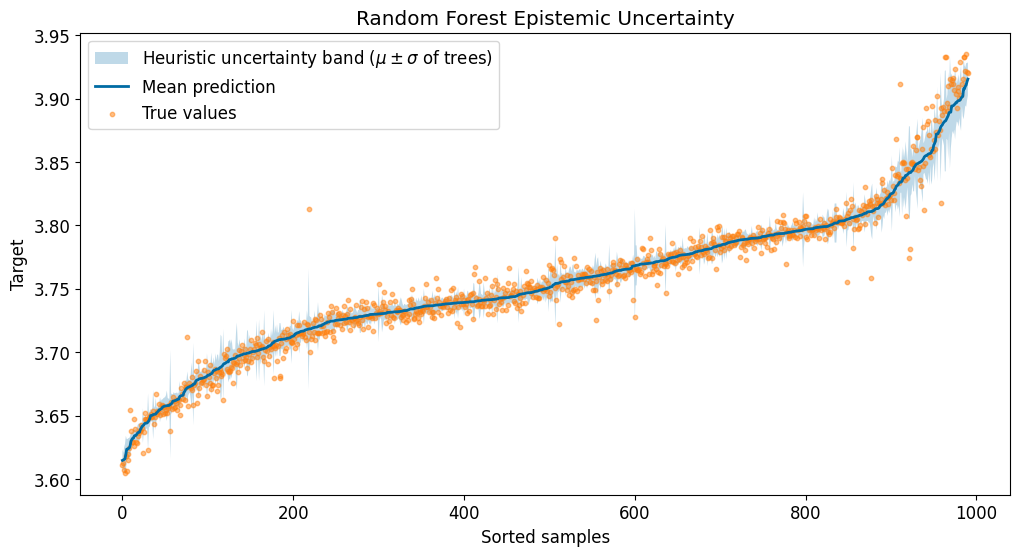

In [11]:
# predictions
rf_low_pred_test  = rf_mean_pred_test - rf_std_pred_test
rf_high_pred_test = rf_mean_pred_test + rf_std_pred_test

# sort by prediction (IMPORTANT for clean plot)
idx = np.argsort(rf_mean_pred_test)

rf_low_pred_test_sorted  = rf_low_pred_test[idx]
rf_mean_pred_test_sorted = rf_mean_pred_test[idx]
rf_high_pred_test_sorted = rf_high_pred_test[idx]

y_test_sorted = y_test[idx]
x = np.arange(len(rf_mean_pred_test_sorted))

plt.figure(figsize=(12,6))

# uncertainty band
plt.fill_between(x, rf_low_pred_test_sorted, rf_high_pred_test_sorted, alpha=0.25, 
                 label=r"Heuristic uncertainty band ($\mu \pm \sigma$ of trees)")

# median prediction
plt.plot(x, rf_mean_pred_test_sorted, label="Mean prediction", linewidth=2)

# true values
plt.scatter(x, y_test_sorted, s=10, alpha=0.5, label="True values")

plt.legend()
plt.title("Random Forest Epistemic Uncertainty")
plt.xlabel("Sorted samples")
plt.ylabel("Target")
plt.show()

## Empirical coverage of heuristic uncertainty bands

We evaluate how often the interval: $[\mu - \sigma,\; \mu + \sigma]$ contains the true value.

Because $\sigma_{\mathrm{RF}}$ is **not a calibrated standard deviation**, there is **no theoretical expected coverage** (e.g. 68%). This metric is therefore diagnostic only:

* low coverage → intervals are too narrow relative to errors  
* high coverage → intervals are overly wide  
* no target value → unlike probabilistic models, there is no “correct” level  

This test helps assess whether ensemble spread is at least **monotonically related to error**, but not whether it is statistically calibrated.

In [12]:
rf_inside = np.mean((y_test >= rf_low_pred_test) & (y_test <= rf_high_pred_test))
print("Empirical coverage of [mu-sigma,mu+sigma] interval:", rf_inside)


Empirical coverage of [mu-sigma,mu+sigma] interval: 0.7013118062563067


## Probabilistic evaluation (Gaussian approximation)

We approximate the Random Forest predictions as: $y \sim \mathcal{N}(\mu_{\text{RF}}, \sigma_{\text{RF}})$

This assumption is **not derived from the model** and is imposed purely for comparison.

As a result:

* the likelihood is misspecified  
* the score is not strictly proper for this model  
* absolute values of NLL are not statistically meaningful  

NLL can still be used as a **relative diagnostic**:

* lower NLL → better joint behaviour of predictions and spread  
* comparisons to true probabilistic models (e.g. NGBoost) should be made cautiously  

This is best viewed as a **consistency check**, not a principled probabilistic evaluation.

In [13]:
# This assumes Gaussianity and is only approximate
print("RF Approximate Gaussian NLL:",
      gaussian_nll(y_test, rf_mean_pred_test, rf_std_pred_test))


RF Approximate Gaussian NLL: -3.4031681667300155


### Uncertainty–error relationship (Random Forest)

This plot compares the model’s **predicted uncertainty** with its **actual error** per test sample.

* x-axis: ensemble spread $\sigma_{\text{RF}} = \mathrm{std}(f_t(x))$

* y-axis: absolute error $|\hat{y} - y|$

Is uncertainty **meaningful**:

> do higher predicted uncertainties correspond to larger errors?

A good model shows a **wedge shape**:

* low uncertainty → small errors
* high uncertainty → larger spread in errors

###### Failure modes

* no trend → uninformative uncertainty
* low $\sigma$, high error → overconfident
* high $\sigma$, low error → overly cautious

Good uncertainty should track real error:

> more uncertainty should generally mean higher risk of being wrong.


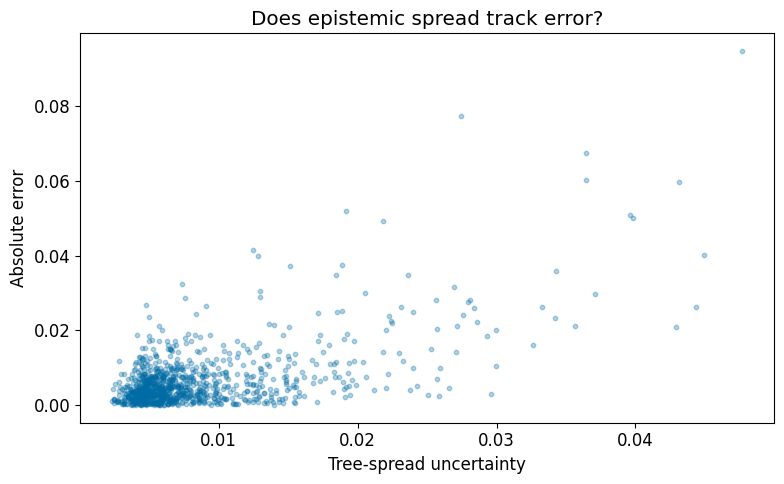

In [14]:
plt.scatter(rf_std_pred_test, np.abs(y_test - rf_mean_pred_test), s=10, alpha=0.3)
plt.xlabel("Tree-spread uncertainty")
plt.ylabel("Absolute error")
plt.title("Does epistemic spread track error?")
plt.tight_layout()
plt.show()


## Uncertainty Reliability Diagram

The reliability diagram tests whether predicted uncertainties correspond to empirical error frequencies.

For predictions with mean $\mu(x)$ and standard deviation $\sigma(x)$, define the normalized residual:

$
z = \frac{|y-\mu(x)|}{\sigma(x)}
$

If the model is well calibrated and approximately Gaussian, then $z$ should follow a standard normal distribution.

> If I assume a Gaussian distribution, what percentage of data should fall within $b$ standard deviations?

For example:

- if $b=1$ ($1 \sigma$), the "Ideal" coverage is roughly 68%.

- if $b=2$ ($2 \sigma$), the "Ideal" coverage is roughly 95%.

The **empirical coverage** counts: 

> What percentage of my actual errors were actually smaller than what I predicted?

Note, however, that this is an approximate calibration diagnostic rather than a formal probabilistic scoring rule.

- empirical curve below diagonal → overconfident uncertainties
- empirical curve above diagonal → underconfident uncertainties
- agreement with diagonal → good calibration

Unlike RMSE or MAE, this diagnostic evaluates the statistical reliability of uncertainty estimates.

In [15]:
def get_calibration_metrics(y_true, mu, sigma, n_bins=20):
    """
    Calculates the theoretical vs empirical coverage for a Gaussian uncertainty model.
    """
    # 1. Calculate the absolute z-score (number of standard deviations from truth)
    z = np.abs((y_true - mu) / np.clip(sigma, 1e-6, None))
    
    # 2. Create bins for z-scores (from 0 to 3 sigma)
    # We use more bins (20) for a smoother curve
    z_thresholds = np.linspace(0, 3, n_bins)
    
    # 3. Calculate empirical coverage: what % of data actually falls within 'b' sigma?
    empirical = [np.mean(z <= b) for b in z_thresholds]
    
    # 4. Calculate theoretical coverage: what % SHOULD fall within 'b' sigma?
    # For Gaussian: 1 sigma ~68%, 2 sigma ~95%, etc.
    theoretical = stats.norm.cdf(z_thresholds) * 2 - 1
    
    return theoretical, empirical

def plot_reliability_diagram(calibration_data, title="Reliability Diagram"):
    """
    Plots the reliability diagram for one or more models.
    'calibration_data' should be a dictionary: {"Model Name": (theoretical, empirical)}
    """
    plt.figure(figsize=(7, 7))
    
    # Plot the 1:1 line (Perfect Calibration)
    plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration", alpha=0.8)
    
    # Iterate through models and plot their curves
    for model_name, (theoretical, empirical) in calibration_data.items():
        plt.plot(theoretical, empirical, marker="o", markersize=4, label=model_name)
    
    plt.xlabel("Expected Confidence (Theoretical)")
    plt.ylabel("Observed Coverage (Empirical)")
    plt.title(title)
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    
    # Make it a perfect square
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

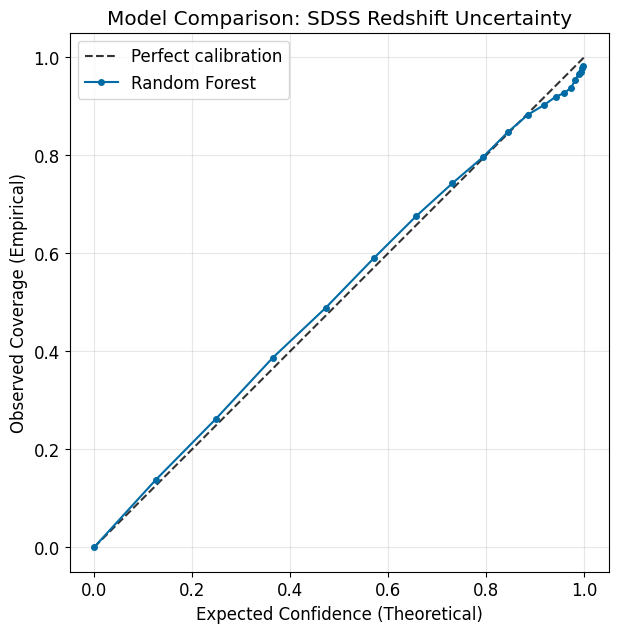

In [16]:
rf_theo, rf_emp = get_calibration_metrics(y_test, rf_mean_pred_test, rf_std_pred_test)
comparison_dict = {"Random Forest": (rf_theo, rf_emp ),}
plot_reliability_diagram(comparison_dict, title="Model Comparison: SDSS Redshift Uncertainty")


## Probabilistic regression with NGBoost

Standard regression predicts a single value: $\hat{y}(x)$

NGBoost instead models a full predictive distribution: $p(y \mid x)$

Assuming a Gaussian likelihood:

$
p(y \mid x)=\mathcal{N}(\mu(x),\sigma^2(x))
$

the model predicts both:

- $\mu(x)$: expected temperature
- $\sigma(x)$: predictive uncertainty

Training minimizes the Gaussian negative log-likelihood, encouraging both accurate predictions and realistic uncertainties.

### Conditioning on observational quality

We include photometric uncertainty as an additional feature:

$
p(y \mid x,\sigma_{\rm phot})
$

This allows the predictive uncertainty to adapt to measurement quality.

> When the input features are blurry (high $\sigma_{\rm phot}$), the model should output a wider predictive distribution.

NGBoost uncertainty is model-dependent.

It is not a clean separation of aleatoric and epistemic uncertainty, and depends on:

- the assumed likelihood
- the training distribution
- the chosen feature representation

[iter 0] loss=-1.4162 val_loss=-1.3449 scale=1.0000 norm=0.5344
[iter 100] loss=-1.5623 val_loss=-1.5125 scale=2.0000 norm=0.8550
[iter 200] loss=-1.6915 val_loss=-1.6529 scale=2.0000 norm=0.7391
[iter 300] loss=-1.7993 val_loss=-1.7660 scale=2.0000 norm=0.7113
[iter 400] loss=-1.8955 val_loss=-1.8645 scale=2.0000 norm=0.7299
[iter 500] loss=-1.9908 val_loss=-1.9608 scale=2.0000 norm=0.7630
[iter 600] loss=-2.0829 val_loss=-2.0532 scale=2.0000 norm=0.7927
[iter 700] loss=-2.1748 val_loss=-2.1448 scale=2.0000 norm=0.8175
[iter 800] loss=-2.2648 val_loss=-2.2339 scale=2.0000 norm=0.8364
[iter 900] loss=-2.3528 val_loss=-2.3206 scale=2.0000 norm=0.8501
[iter 1000] loss=-2.4382 val_loss=-2.4044 scale=2.0000 norm=0.8588
[iter 1100] loss=-2.5211 val_loss=-2.4852 scale=2.0000 norm=0.8640
[iter 1200] loss=-2.6021 val_loss=-2.5636 scale=2.0000 norm=0.8670
[iter 1300] loss=-2.6798 val_loss=-2.6382 scale=2.0000 norm=0.8673
[iter 1400] loss=-2.7548 val_loss=-2.7097 scale=2.0000 norm=0.8666
[iter 1

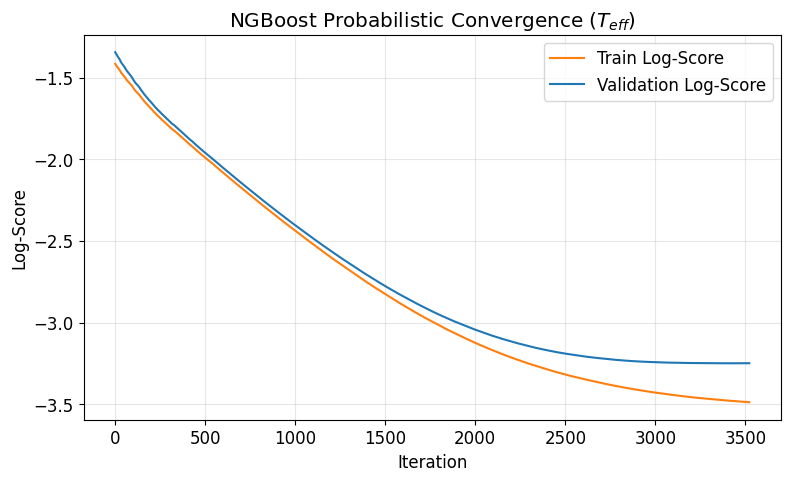

In [19]:
# Initialize the model
ngb = NGBRegressor(
    Dist=Normal, 
    n_estimators=10000, 
    learning_rate=0.001,
    Base=DecisionTreeRegressor(
        max_depth=4, 
        min_samples_leaf=15,   
        max_features='sqrt'   
    ),
    col_sample=0.7,
    verbose=True
)

# Notice that:
# - likelihood training already models heteroscedasticity
# - weighting can sometimes destabilize optimization
# For this reason we do not fit with: sample_weight=w_train
ngb.fit(
    X_train, y_train, 
    X_val=X_val, 
    Y_val=y_val,
    early_stopping_rounds=100
)

# Predict as before
ngb_preds_test = ngb.pred_dist(X_test)
ngb_mean_pred_test = ngb_preds_test.loc
ngb_std_pred_test = ngb_preds_test.scale


# The Log-Likelihood score
train_scores = ngb.evals_result["train"]["LOGSCORE"]

val_scores = ngb.evals_result["val"]["LOGSCORE"]

plt.figure(figsize=(9, 5))
plt.plot(train_scores, color='tab:orange', label='Train Log-Score')
plt.plot(val_scores, color='tab:blue', label='Validation Log-Score')

plt.title("NGBoost Probabilistic Convergence ($T_{eff}$)")
plt.xlabel("Iteration")
plt.ylabel("Log-Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Visualising predictive uncertainty (NGBoost)

NGBoost predicts a model-dependent approximation to predictive uncertainty for each star: $\mu(x), \sigma(x)$

We visualise the interval:

$\mu(x) \pm \sigma(x)$

###### Important clarification

Under a correct Gaussian model, this would correspond to a ~68% prediction interval.

However, in practice this interpretation is only valid if:

* the Gaussian assumption is appropriate  
* the model is well calibrated  

Therefore, this interval should be interpreted as a **model-based uncertainty band**, not guaranteed coverage.

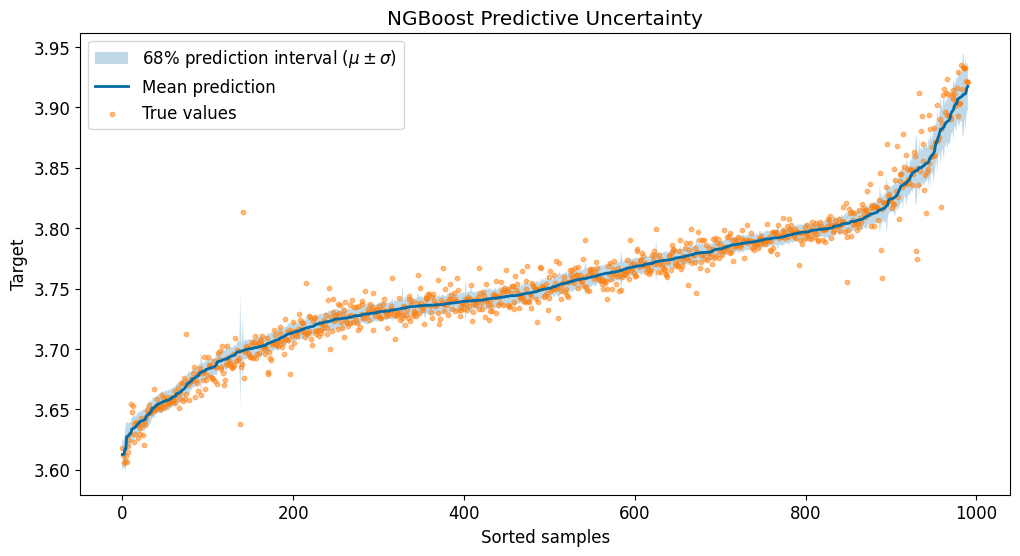

In [20]:
# predictions
ngb_low_pred_test  = ngb_mean_pred_test - ngb_std_pred_test
ngb_high_pred_test = ngb_mean_pred_test + ngb_std_pred_test

# sort by prediction (IMPORTANT for clean plot)
idx = np.argsort(ngb_mean_pred_test)

ngb_low_pred_test_sorted  = ngb_low_pred_test[idx]
ngb_mean_pred_test_sorted = ngb_mean_pred_test[idx]
ngb_high_pred_test_sorted = ngb_high_pred_test[idx]

y_true_sorted = y_test[idx]
x = np.arange(len(ngb_mean_pred_test))

plt.figure(figsize=(12,6))

# uncertainty band
plt.fill_between(x, ngb_low_pred_test_sorted, ngb_high_pred_test_sorted, alpha=0.25, 
                 label=r"68% prediction interval $(\mu\pm\sigma)$")

# median prediction
plt.plot(x, ngb_mean_pred_test_sorted, label="Mean prediction", linewidth=2)

# true values
plt.scatter(x, y_true_sorted, s=10, alpha=0.5, label="True values")

plt.legend()
plt.title("NGBoost Predictive Uncertainty")
plt.xlabel("Sorted samples")
plt.ylabel("Target")
plt.show()

### Empirical coverage of NGBoost uncertainty intervals

We compute the fraction of true values inside:

$[\mu(x) - \sigma(x), \; \mu(x) + \sigma(x)]$

If the model is:

* correctly specified (Gaussian residuals)  
* well calibrated  

then this interval should contain ≈68% of the data.

* **< 68%** → overconfident (uncertainty underestimated)  
* **> 68%** → underconfident (uncertainty overestimated)  

Because real data may violate Gaussian assumptions, this test evaluates **approximate calibration**, not exact probabilistic correctness.

In [21]:
ngb_inside = np.mean((y_test >= ngb_low_pred_test) & (y_test <= ngb_high_pred_test))
print("Empirical coverage of [mu-sigma,mu+sigma] interval:", ngb_inside)


Empirical coverage of [mu-sigma,mu+sigma] interval: 0.6912209889001009


### Probabilistic evaluation (NGBoost via Gaussian NLL)

To assess NGBoost as a probabilistic model, we evaluate it using the Gaussian Negative Log-Likelihood (NLL), treating its outputs as defining a Gaussian predictive distribution:

$
y \sim \mathcal{N}(\mu(x), \sigma(x))
$

Because NGBoost is trained directly by likelihood maximization:

* NLL is consistent with the training objective
* comparisons across models are statistically valid
* uncertainty is part of the learned predictive distribution

> good NLL does not guarantee that the Gaussian assumption is correct


In [22]:
print("NGBoost Approximate Gaussian NLL:",
      gaussian_nll(y_test, ngb_mean_pred_test, ngb_std_pred_test))


NGBoost Approximate Gaussian NLL: -3.2909776255800636


## Uncertainty Reliability Diagram


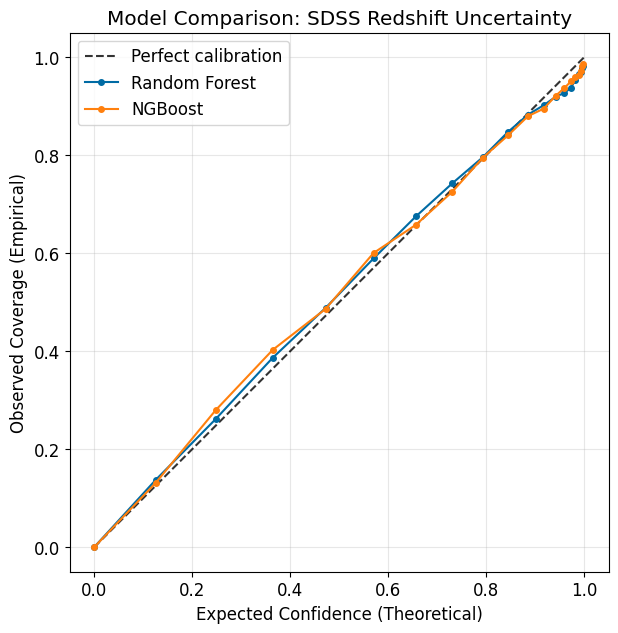

In [23]:
ngb_theo, ngb_emp = get_calibration_metrics(y_test, ngb_mean_pred_test, ngb_std_pred_test)
comparison_dict["NGBoost"] =  (ngb_theo, ngb_emp)
plot_reliability_diagram(comparison_dict, title="Model Comparison: SDSS Redshift Uncertainty")


## What NGBoost uncertainty represents

### It is:

* likelihood-based predictive uncertainty
* heteroscedastic (input-dependent variance)
* directly trained from data

### It is not:

* a decomposition into epistemic vs aleatoric components
* guaranteed correct under model misspecification
* independent of distributional assumptions


## Probabilistic stellar temperature inference with quantile regression

Point predictions alone are often insufficient for photometric stellar inference because multiple physical configurations can produce similar colours.

Instead of predicting only a central estimate, quantile regression learns selected conditional quantiles of the target distribution:

- $Q_{10}$: lower bound
- $Q_{50}$: median prediction
- $Q_{90}$: upper bound

Together, these define an approximate predictive interval:

$
[Q_{10}, Q_{90}]
$

Wide intervals indicate ambiguous or noisy regions of feature space, while narrow intervals indicate well-constrained predictions.

### Quantile loss

Each quantile is trained independently using the pinball loss:

$
L_\alpha(y,\hat{y}) =
\max\left(\alpha(y-\hat{y}), (\alpha-1)(y-\hat{y})\right)
$

Different values of $\alpha$ emphasize different parts of the conditional distribution.

### Model implementation

We use gradient-boosted decision trees (XGBoost) configured for quantile regression.

Separate models are trained for:

- $\alpha = 0.1$
- $\alpha = 0.5$
- $\alpha = 0.9$

The feature space includes both photometric colours and observational uncertainty $\sigma_{\rm phot}$, allowing the prediction intervals to adapt to data quality.

### Important caveat

Because the quantiles are trained independently, quantile crossing may occur:

$
Q_{10}(x) > Q_{50}(x)
$

particularly in sparse or noisy regions of feature space.

In [28]:
# DATA
xgb_dtrain = xgb.DMatrix(X_train, label=y_train)
xgb_dval    = xgb.DMatrix(X_val,  label=y_val)
xgb_dtest   = xgb.DMatrix(X_test, label=y_test)
xgb_y_dtest = xgb_dtest.get_label()

# TRAINING PARAMETERS
xgb_base_params = {
    "objective": "reg:quantileerror",
    "max_depth": 6,
    "learning_rate": 0.005,
    "subsample": 0.75,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "min_child_weight": 15,
    "gamma": 0.5,
    "max_delta_step": 1,
    "eval_metric": "quantile",
    "verbosity": 0
}

num_boost_round = 10000

# QUANTILES
xgb_alphas = {
    "low": 0.1,
    "mid": 0.5,
    "high": 0.9
}

# TRAIN MODELS
xgb_models = {}
for name, a in xgb_alphas.items():
    print(f"--- Training quantile model: {name} (alpha={a}) ---")

    params = xgb_base_params.copy()
    params["quantile_alpha"] = a

    # The model will monitor the LAST entry in 'evals' (xgb_dtest)
    xgb_models[name] = xgb.train(
        params=params,
        dtrain=xgb_dtrain,
        num_boost_round=num_boost_round,
        evals=[(xgb_dtrain, "train"), (xgb_dval, "val")],
        early_stopping_rounds=100,   # Stop if 'test' quantile loss doesn't improve for 50 rounds
        verbose_eval=100
    )
    
    print(f"Best iteration for {name}: {xgb_models[name].best_iteration}\n")

# PREDICTIONS 
# Note: predict() automatically uses the 'best_iteration' found during early stopping
xgb_low_pred_test    = xgb_models["low"].predict(xgb_dtest)
xgb_median_pred_test = xgb_models["mid"].predict(xgb_dtest)
xgb_high_pred_test   = xgb_models["high"].predict(xgb_dtest)

# UNCERTAINTY INTERVAL
# width of uncertainty
xgb_uncertainty = xgb_high_pred_test - xgb_low_pred_test

# OUTPUT STRUCTURE
xgb_results = {
    "lower": xgb_low_pred_test,
    "median": xgb_median_pred_test,
    "upper": xgb_high_pred_test,
    "uncertainty_width": xgb_uncertainty
}

--- Training quantile model: low (alpha=0.1) ---
[0]	train-quantile:0.01056	val-quantile:0.01104
[100]	train-quantile:0.00768	val-quantile:0.00810
[200]	train-quantile:0.00624	val-quantile:0.00664
[300]	train-quantile:0.00538	val-quantile:0.00582
[400]	train-quantile:0.00475	val-quantile:0.00523
[500]	train-quantile:0.00426	val-quantile:0.00478
[600]	train-quantile:0.00383	val-quantile:0.00436
[700]	train-quantile:0.00341	val-quantile:0.00394
[800]	train-quantile:0.00306	val-quantile:0.00358
[900]	train-quantile:0.00275	val-quantile:0.00326
[1000]	train-quantile:0.00251	val-quantile:0.00302
[1100]	train-quantile:0.00231	val-quantile:0.00283
[1200]	train-quantile:0.00216	val-quantile:0.00267
[1300]	train-quantile:0.00204	val-quantile:0.00255
[1400]	train-quantile:0.00197	val-quantile:0.00248
[1500]	train-quantile:0.00191	val-quantile:0.00241
[1600]	train-quantile:0.00184	val-quantile:0.00233
[1700]	train-quantile:0.00179	val-quantile:0.00227
[1800]	train-quantile:0.00175	val-quantile:0.

## Quantile regression evaluation

To evaluate quantile regression we use the pinball (quantile) loss:

$
L_\alpha(y,\hat{y}) =
\max\big(\alpha(y-\hat{y}),(\alpha-1)(y-\hat{y})\big)
$

Each quantile model is optimized independently:

- $Q_{10}$ → lower tail
- $Q_{50}$ → median
- $Q_{90}$ → upper tail

Lower loss indicates better agreement with the target conditional quantile.

Together, the quantiles approximate the conditional distribution of stellar temperatures without assuming Gaussianity.

In [29]:
def quantile_loss(y_true, y_pred, alpha):
    e = y_true - y_pred
    return np.mean(np.maximum(alpha * e, (alpha - 1) * e))

print("Quantile losses:")
print("Q10:", quantile_loss(xgb_y_dtest, xgb_low_pred_test, 0.1))
print("Q50:", quantile_loss(xgb_y_dtest, xgb_median_pred_test, 0.5))
print("Q90:", quantile_loss(xgb_y_dtest, xgb_high_pred_test, 0.9))

Quantile losses:
Q10: 0.0018407232
Q50: 0.0032205447
Q90: 0.0016875445


### Quantile regression uncertainty (XGBoost)

We visualise the predicted distribution from quantile regression.

Samples are sorted by the median prediction $Q_{50}$ for clarity.

###### Plot contents

* x-axis: sorted by $Q_{50}$
* y-axis: $\log_{10}(T_{\rm eff})$
* line: median $Q_{50}$
* band: $Q_{10}–Q_{90}$ interval
* points: true values

The model expresses **full predictive uncertainty**, showing where stellar temperatures are well-constrained versus ambiguous.


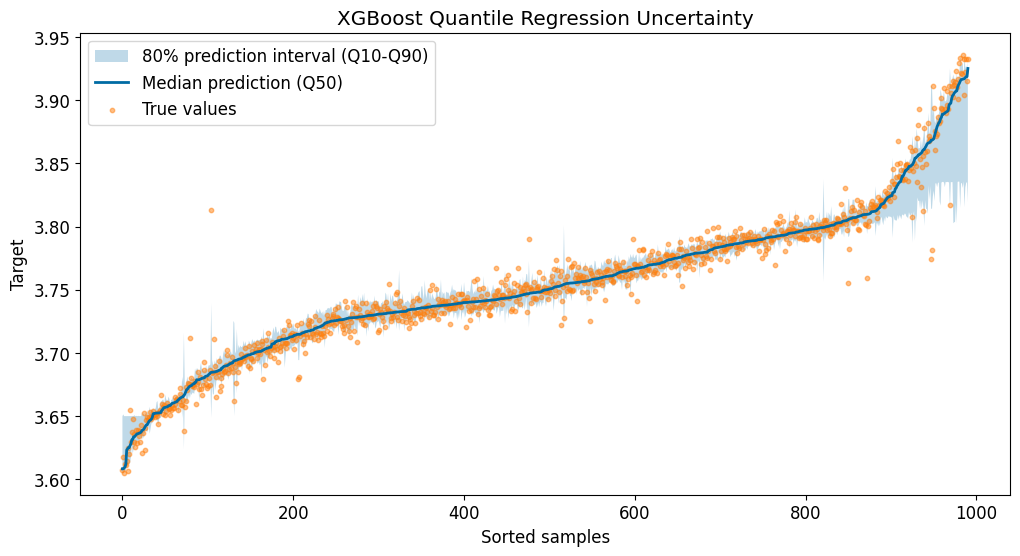

In [30]:
# sort by prediction (IMPORTANT for clean plot)
idx = np.argsort(xgb_median_pred_test)

xgb_low_pred_test_sorted = xgb_low_pred_test[idx]
xgb_median_pred_test_sorted = xgb_median_pred_test[idx]
xgb_high_pred_test_sorted = xgb_high_pred_test[idx]
xgb_y_test_sorted = xgb_y_dtest[idx]

x = np.arange(len(xgb_median_pred_test))

plt.figure(figsize=(12,6))

# uncertainty band
plt.fill_between(x, xgb_low_pred_test_sorted, xgb_high_pred_test_sorted, alpha=0.25, label="80% prediction interval (Q10-Q90)")

# median prediction
plt.plot(x, xgb_median_pred_test_sorted, label="Median prediction (Q50)", linewidth=2)

# true values
plt.scatter(x, xgb_y_test_sorted, s=10, alpha=0.5, label="True values")

plt.legend()
plt.title("XGBoost Quantile Regression Uncertainty")
plt.xlabel("Sorted samples")
plt.ylabel("Target")
plt.show()

### Empirical coverage of prediction intervals

We check whether predicted uncertainty is statistically reliable by measuring how often true values fall inside the model’s 80% interval.

Fraction of points inside:$[Q_{10}, Q_{90}]$

* $< 0.8$ → overconfident
* $> 0.8$ → too conservative
* $\approx 0.8$ → well calibrated

This tests **probabilistic correctness**, not just accuracy:

> an 80% interval should contain the truth 80% of the time.


In [31]:
xgb_inside = np.mean((y_test >= xgb_low_pred_test) & (y_test <= xgb_high_pred_test))
print("Empirical coverage of [Q10,Q90] interval:", xgb_inside)


Empirical coverage of [Q10,Q90] interval: 0.7588294651866802


### Measurement noise vs prediction error

This plot compares observational data quality with resulting model performance across different regression approaches.

- **X-axis:** photometric noise ($\sigma_{\text{phot}}$)  
- **Y-axis:** absolute prediction error $|\hat{y} - y|$  

It quantifies how strongly measurement uncertainty propagates into final predictive accuracy.

###### Physical interpretation

In astronomical observations, higher photometric noise corresponds to lower signal-to-noise ratio, which limits the amount of information available about stellar properties.

As a result, even a perfect model cannot fully compensate for poor measurements. This introduces a fundamental limit to predictive performance, often referred to as the **noise floor** of the dataset.

###### Expected behaviour

- **Positive trend:** physically expected, as noisier inputs lead to larger errors  
- **Flat relationship:** may indicate the model is insensitive to data quality (a potential issue)  
- **Increased scatter at high noise:** normal consequence of stochastic measurement uncertainty  

###### Interpretation (aleatoric uncertainty)

This diagnostic primarily reflects **aleatoric uncertainty**, i.e. irreducible noise inherent in the observations.

It demonstrates that:

- high-quality measurements lead to consistently better predictions  
- low-quality measurements impose unavoidable error, independent of model complexity  

This relationship highlights that part of the prediction error is not a modelling failure, but a direct consequence of observational limitations:

> the structure of the data itself sets a lower bound on achievable accuracy.

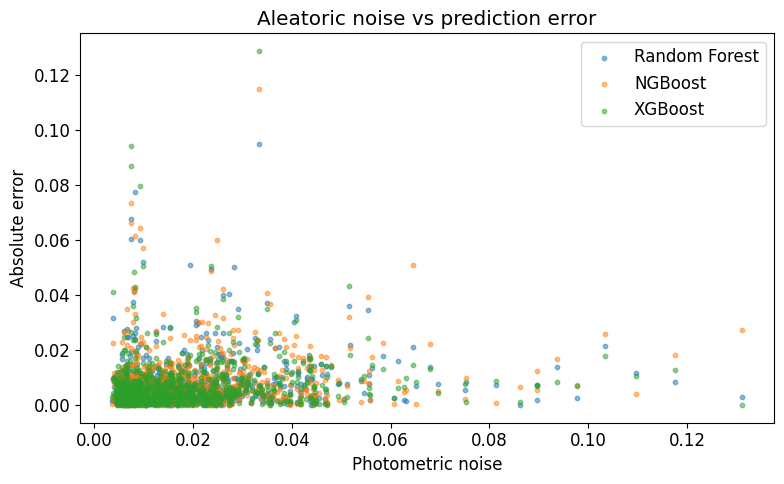

In [32]:
plt.scatter(sig_test, np.abs(y_test - rf_mean_pred_test), s=10, alpha=0.5, color="tab:blue", label="Random Forest")
plt.scatter(sig_test, np.abs(y_test - ngb_mean_pred_test), s=10, alpha=0.5, color="tab:orange", label="NGBoost")
plt.scatter(sig_test, np.abs(y_test - xgb_median_pred_test), s=10, alpha=0.5, color="tab:green", label="XGBoost")

plt.xlabel("Photometric noise")
plt.ylabel("Absolute error")
plt.title("Aleatoric noise vs prediction error")
plt.legend()
plt.tight_layout()
plt.show()

## Distribution comparison (KDE plot)

This plot compares the distribution of predicted temperatures against the true target distribution.

Rather than evaluating individual predictions, it tests whether the models reproduce the overall population structure.

### Interpretation

- good agreement → realistic population-level predictions
- shifted distributions → systematic bias
- incorrect spread → variance mismatch
- missing tails → failure on rare stellar populations

A model can achieve low RMSE while still failing to reproduce the correct astrophysical distribution.

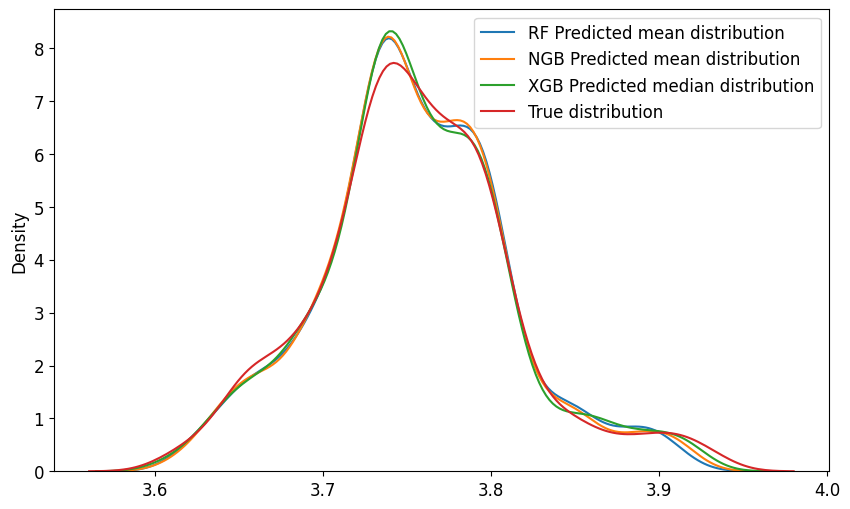

In [33]:
plt.figure(figsize=(10,6))
sns.kdeplot(rf_mean_pred_test, label="RF Predicted mean distribution", color="tab:blue")
sns.kdeplot(ngb_mean_pred_test, label="NGB Predicted mean distribution", color="tab:orange")
sns.kdeplot(xgb_median_pred_test, label="XGB Predicted median distribution", color="tab:green")

sns.kdeplot(y_test, label="True distribution", color="tab:red")
plt.legend()
plt.show()

## Model comparison (point prediction performance)

This table summarises the performance of different regression approaches using standard point-estimate metrics.

Each model is evaluated on the same held-out test set using its central prediction:

- Random Forest → mean of trees  
- NGBoost → predicted mean of Gaussian distribution  
- Quantile model → median ($Q_{50}$)

###### Metrics used

- **RMSE:** penalises large errors more strongly; sensitive to outliers  
- **MAE:** average absolute deviation; more robust and directly interpretable  
- **$R^2$:** fraction of variance explained by the model  

###### Interpretation

This comparison focuses purely on **point prediction accuracy**, ignoring uncertainty estimates.

- **Lower RMSE / MAE:** better predictive accuracy  
- **Higher $R^2$:** better explanation of variance in stellar temperatures  

However, differences between models should be interpreted in context:

- Random Forest: strong nonlinear regression baseline  
- NGBoost: similar accuracy, but additionally provides calibrated uncertainty  
- Quantile median: robust central estimator, less sensitive to distributional assumptions  

These metrics do **not** evaluate uncertainty quality.

A model can achieve excellent RMSE while still producing poorly calibrated or misleading uncertainty estimates. 

This is why these results should always be interpreted alongside probabilistic diagnostics (coverage, NLL, calibration curves).

In [34]:
results = []

results.append(evaluate_model("Random Forest", y_test, rf_mean_pred_test))
results.append(evaluate_model("NGBoost", y_test, ngb_mean_pred_test))
results.append(evaluate_model("Quantile Median", y_test, xgb_median_pred_test))

results_df = pd.DataFrame(results)
print(results_df)


             Model  RMSE [dex]  MAE [dex]        R2
0    Random Forest    0.010765   0.006742  0.966693
1          NGBoost    0.011629   0.007403  0.961129
2  Quantile Median    0.010867   0.006441  0.966054


## Classic residual diagnostic plot

This helps students identify:
- heteroscedasticity
- bias
- regime-dependent failure

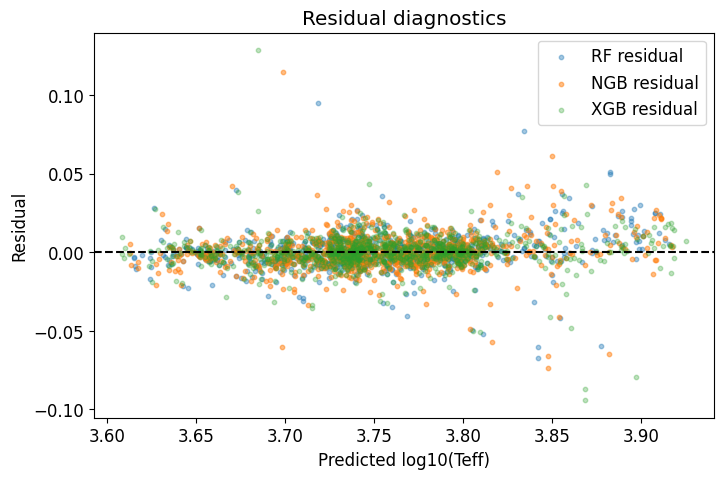

In [35]:
ngb_residuals = y_test - ngb_mean_pred_test
rf_residuals = y_test - rf_mean_pred_test
xgb_residuals = y_test - xgb_median_pred_test
plt.scatter(rf_mean_pred_test, rf_residuals, s=10, alpha=0.4, label="RF residual", color="tab:blue")
plt.scatter(ngb_mean_pred_test, ngb_residuals, s=10, alpha=0.5, label="NGB residual", color="tab:orange")
plt.scatter(xgb_median_pred_test, xgb_residuals, s=10, alpha=0.3, label="XGB residual", color="tab:green")

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Predicted log10(Teff)")
plt.ylabel("Residual")
plt.title("Residual diagnostics")
plt.legend()
plt.show()

### Distribution shift

Models trained on one stellar population may fail on another due to:

- different metallicity distributions
- survey selection effects
- photometric system changes

Uncertainty estimates may become unreliable under such shifts.

## Scientific interpretation

These results show that broadband photometry contains enough information to infer stellar effective temperature with high accuracy, particularly when nonlinear models are used.

However, uncertainty is an intrinsic part of the problem.

### Main conclusions

- The colour–temperature relation is nonlinear and affected by metallicity and observational noise.
- Photometric uncertainty introduces a fundamental error floor that cannot be removed by increasing model complexity.
- Probabilistic models provide more scientifically useful outputs than deterministic regressors because they quantify predictive uncertainty.
- Calibration is as important as predictive accuracy: a model should know when it is likely to fail.

### Limitations

- Photometric colours alone cannot fully break degeneracies between temperature and metallicity.
- Random Forest uncertainty is heuristic rather than probabilistically calibrated.
- NGBoost depends on the assumed likelihood model.
- Quantile regression captures predictive spread but does not define a full probability distribution.
- Survey systematics and selection effects are not explicitly modeled.

### Key takeaway

- Random Forest spread is heuristic
- NGBoost learns a likelihood model
- Quantile regression avoids Gaussian assumptions
- Calibration matters more than RMSE alone

## Conclusion

Inferring stellar parameters from photometry is fundamentally a problem of probabilistic inference under noisy and incomplete information.

In this notebook we explored:

- deterministic regression
- likelihood-based probabilistic models
- quantile-based uncertainty estimation
- calibration diagnostics

The central goal is not only to predict stellar temperatures, but also to quantify how reliable those predictions are.

In scientific machine learning, uncertainty estimation is part of the modelling problem itself.